In [1]:
%load_ext autoreload
%autoreload 2
%load_ext line_profiler
import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda.hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE
from mne.decoding import Scaler
from mne import combine_evoked

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
fmax=16
sfreq=fmax*2
paradigm = P300(resample=sfreq, tmin=0, tmax=0.7, fmin=0.5, fmax=fmax)
dataset = BNCI2014008()

In [3]:
subject, session, run = 1, "session_0", "run_0"
dataset.download(subject_list=[subject])
data = dataset.get_data(subjects=[subject])
raw = data[subject][session][run]
raw.info
epochs, labels, _ = paradigm.process_raw(raw, dataset, return_epochs=True)
epochs

Creating RawArray with float64 data, n_channels=10, n_times=347704
    Range : 0 ... 347703 =      0.000 ...  1358.215 secs
Ready.
Not setting metadata
4200 matching events found
No baseline correction applied


Number of events,4200
Events,NonTarget: 3500Target: 700
Time range,0.000 – 0.656 sec
Baseline,off


No projector specified for this dataset. Please consider the method self.add_proj.


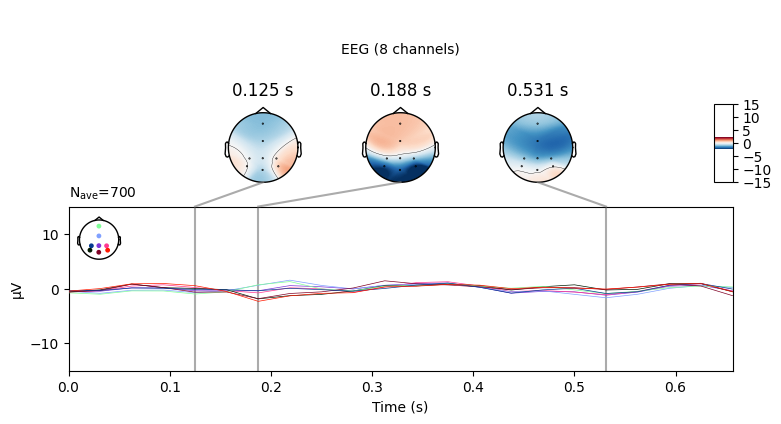

No projector specified for this dataset. Please consider the method self.add_proj.


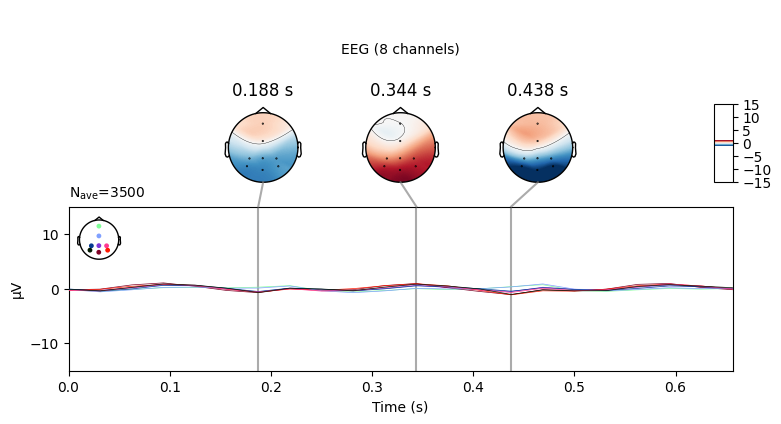

No projector specified for this dataset. Please consider the method self.add_proj.


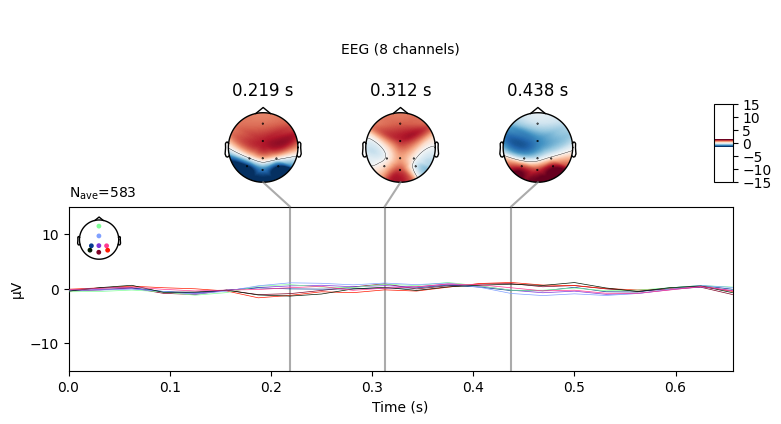

In [4]:
from mne import combine_evoked
target = epochs['Target'].average()
_ = target.plot_joint(ts_args=dict(ylim=dict(eeg=[-15,15])))
non_target = epochs['NonTarget'].average()
_ = non_target.plot_joint(ts_args=dict(ylim=dict(eeg=[-15,15])))
contrast = combine_evoked([target, non_target], weights=[1,-1])
_= contrast.plot_joint(ts_args=dict(ylim=dict(eeg=[-15,15])))

In [5]:
contrast = combine_evoked([epochs['Target'].average(), epochs['NonTarget'].average()], weights=[1,-1])

In [6]:
split = len(epochs)//2
epochs_train = epochs[:split]
epochs_test = epochs[split:]
labels_train = labels[:split]
labels_test = labels[split:]

In [21]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl

tl.set_backend('cupy')

X_train = tl.tensor(epochs_train.get_data().astype(np.float32))
y_train = labels_train
X_test = tl.tensor(epochs_test.get_data().astype(np.float32))
y_test = labels_test

X_train /= np.std(X_train, axis=0)[np.newaxis,:,:]
X_test /= np.std(X_train, axis=0)[np.newaxis,:,:]
"""
print(X_train.shape)
X_train, factors = tensorly.decomposition.partial_tucker(X_train, modes=(1,), rank=8)
factors = [factors[0],tl.eye(X_train.shape[2])]
print(X_train.shape)
X_test = tensorly.tenalg.multi_mode_dot(X_test, factors, modes=(1,), transpose=True)


#plt.semilogy(np.mean(np.abs(X_train), axis=(0,2)), label='space')
#plt.semilogy(np.mean(np.abs(X_train), axis=(0,1)), label='time')
#plt.legend()
"""
factors = [tl.eye(X_train.shape[1]),tl.eye(X_train.shape[2])]


ValueError: Unknown backend name 'cumpy', known backends are ['numpy', 'mxnet', 'pytorch', 'tensorflow', 'cupy', 'jax']

In [22]:
import cupy

#fig, axs = plt.subplots(1, X_train.shape[1], figsize=(16,6))
#for i in range(X_train.shape[1]):
#    w = cupy.asnumpy(factors[0][:,i])
#    plot_topomap(w, epochs.info, axes=axs[i], show=False)


In [9]:
hoda = HODA(max_iter=128, rank=5, tol=1e-3,
            initialize ='svd', verbose=True,
            shrinkage='oas', toeplitz=None)
%lprun -f  hoda.fit hoda.fit(X_train,y_train)
#hoda.fit(X_train,y_train)

[0/128]  shrinkage=0.0012  shrinkage=0.0244  step=3.1713e+00
[1/128]  shrinkage=0.0016  shrinkage=0.0294  step=3.3267e+00
[2/128]  shrinkage=0.0013  shrinkage=0.0228  step=2.9240e+00
[3/128]  shrinkage=0.0016  shrinkage=0.0456  step=3.1058e+00
[4/128]  shrinkage=0.0014  shrinkage=0.0222  step=2.8522e+00
[5/128]  shrinkage=0.0017  shrinkage=0.0611  step=2.8767e+00
[6/128]  shrinkage=0.0014  shrinkage=0.0224  step=2.4791e+00
[7/128]  shrinkage=0.0017  shrinkage=0.0566  step=2.5336e+00
[8/128]  shrinkage=0.0015  shrinkage=0.0228  step=2.5644e+00
[9/128]  shrinkage=0.0016  shrinkage=0.0520  step=2.4382e+00
[10/128]  shrinkage=0.0015  shrinkage=0.0232  step=2.4381e+00
[11/128]  shrinkage=0.0016  shrinkage=0.0488  step=2.0026e+00
[12/128]  shrinkage=0.0015  shrinkage=0.0236  step=1.8908e+00
[13/128]  shrinkage=0.0016  shrinkage=0.0463  step=1.8705e+00
[14/128]  shrinkage=0.0015  shrinkage=0.0239  step=1.8168e+00
[15/128]  shrinkage=0.0016  shrinkage=0.0442  step=1.8016e+00
[16/128]  shrinkag

/data/Workspace/PhD/hoda-bci/hoda/hoda.py:160: UserWarning: The problem size 8 minus the constraints size 0 is too small relative to the block size 5. Using a dense eigensolver instead of LOBPCG.
  w, v = scipy.sparse.linalg.lobpcg(
/data/Workspace/PhD/hoda-bci/hoda/hoda.py:160: UserWarning: The problem size 22 minus the constraints size 0 is too small relative to the block size 5. Using a dense eigensolver instead of LOBPCG.
  w, v = scipy.sparse.linalg.lobpcg(


step=1.7272e+00
[18/128]  shrinkage=0.0015  shrinkage=0.0245  step=1.6559e+00
[19/128]  shrinkage=0.0016  shrinkage=0.0406  step=1.6449e+00
[20/128]  shrinkage=0.0015  shrinkage=0.0247  step=1.5665e+00
[21/128]  shrinkage=0.0016  shrinkage=0.0391  step=1.1149e+00
[22/128]  shrinkage=0.0015  shrinkage=0.0249  step=1.0128e+00
[23/128]  shrinkage=0.0016  shrinkage=0.0376  step=9.9397e-01
[24/128]  shrinkage=0.0015  shrinkage=0.0251  step=9.1281e-01
[25/128]  shrinkage=0.0016  shrinkage=0.0363  step=8.9271e-01
[26/128]  shrinkage=0.0015  shrinkage=0.0253  step=8.3360e-01
[27/128]  shrinkage=0.0016  shrinkage=0.0352  step=8.1296e-01
[28/128]  shrinkage=0.0016  shrinkage=0.0254  step=1.9683e+00
[29/128]  shrinkage=0.0016  shrinkage=0.0341  step=1.9552e+00
[30/128]  shrinkage=0.0016  shrinkage=0.0256  step=1.9222e+00
[31/128]  shrinkage=0.0016  shrinkage=0.0332  step=1.9083e+00
[32/128]  shrinkage=0.0016  shrinkage=0.0257  step=1.8813e+00
[33/128]  shrinkage=0.0016  shrinkage=0.0324  step=1.8

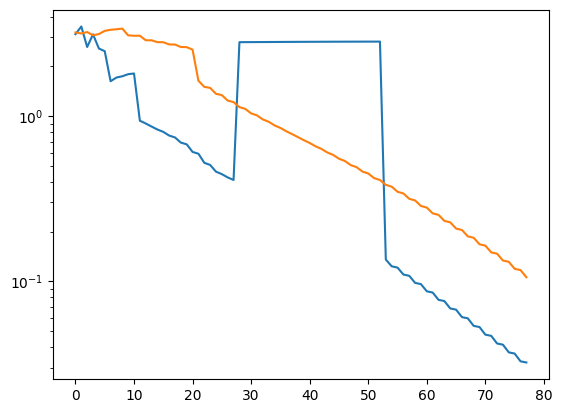

In [10]:
plt.semilogy(cupy.asnumpy(hoda.updates_[:,:hoda.iter_]))
plt.show()

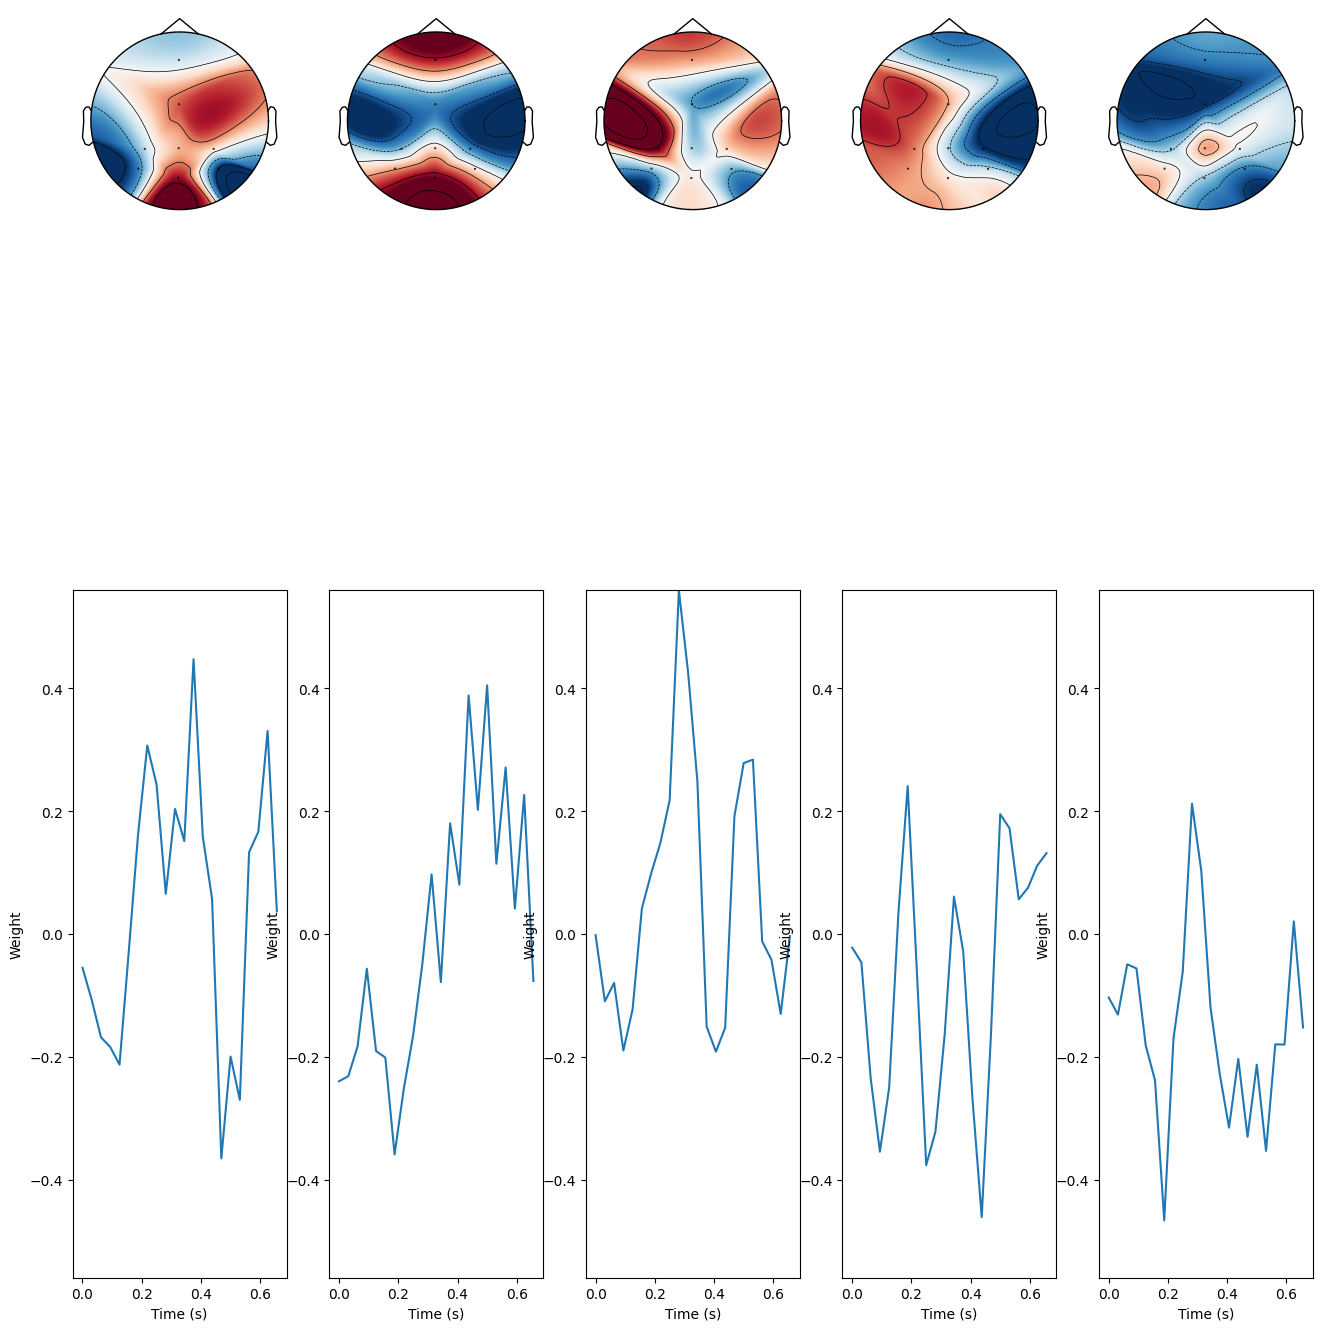

In [11]:

fig, axs = plt.subplots(2,hoda.rank, figsize=(16,6*3))
projs = [factors[k] @ p for k, p in enumerate(hoda.projs_)]
for i in range(hoda.rank):
    w = cupy.asnumpy(projs[0][:,i])
    plot_topomap(w, epochs.info, axes=axs[0,i], show=False)
vmax = np.max(np.abs(projs[1]))
for i in range(hoda.rank):
    w = cupy.asnumpy(projs[1][:,i])
    axs[1,i].plot(epochs.times, w)
    axs[1,i].set_xlabel('Time (s)')
    axs[1,i].set_ylabel('Weight')
    axs[1,i].set_ylim([-vmax, vmax])


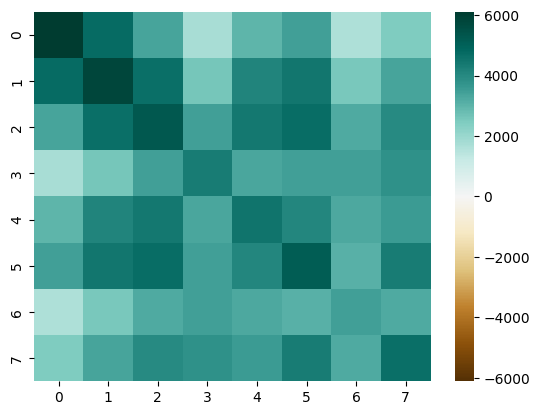

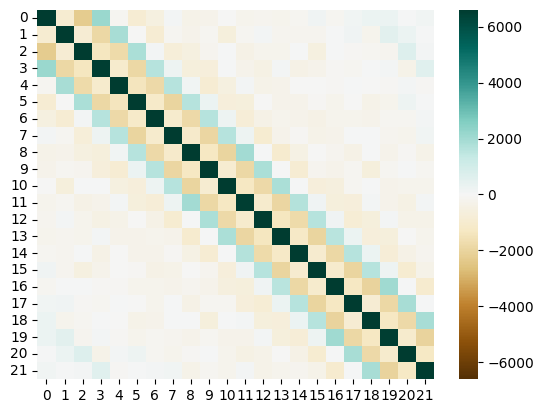

In [12]:
for k in range(2):
    cov = cupy.asnumpy(hoda.scatter_w_[k])
    vmax = np.max(np.abs(cov))
    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax)
    plt.show()

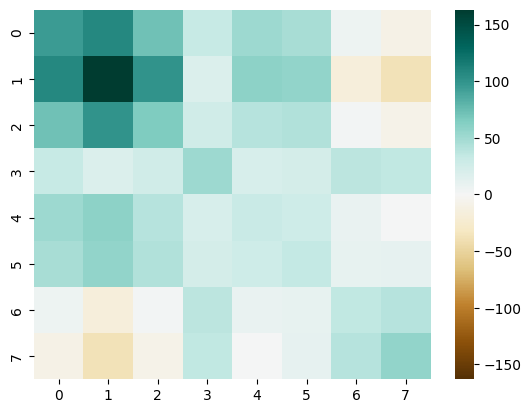

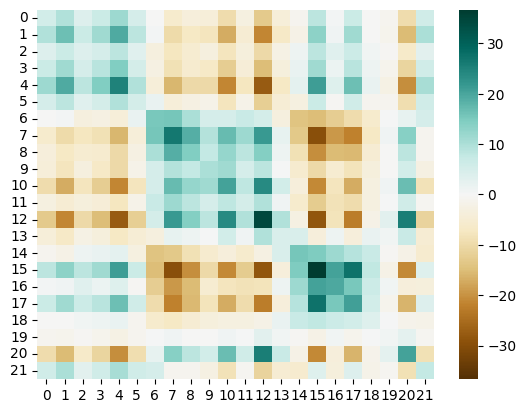

In [13]:
for k in range(2):
    cov = cupy.asnumpy(hoda.scatter_b_[k])
    vmax = np.max(np.abs(cov))
    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax)
    plt.show()

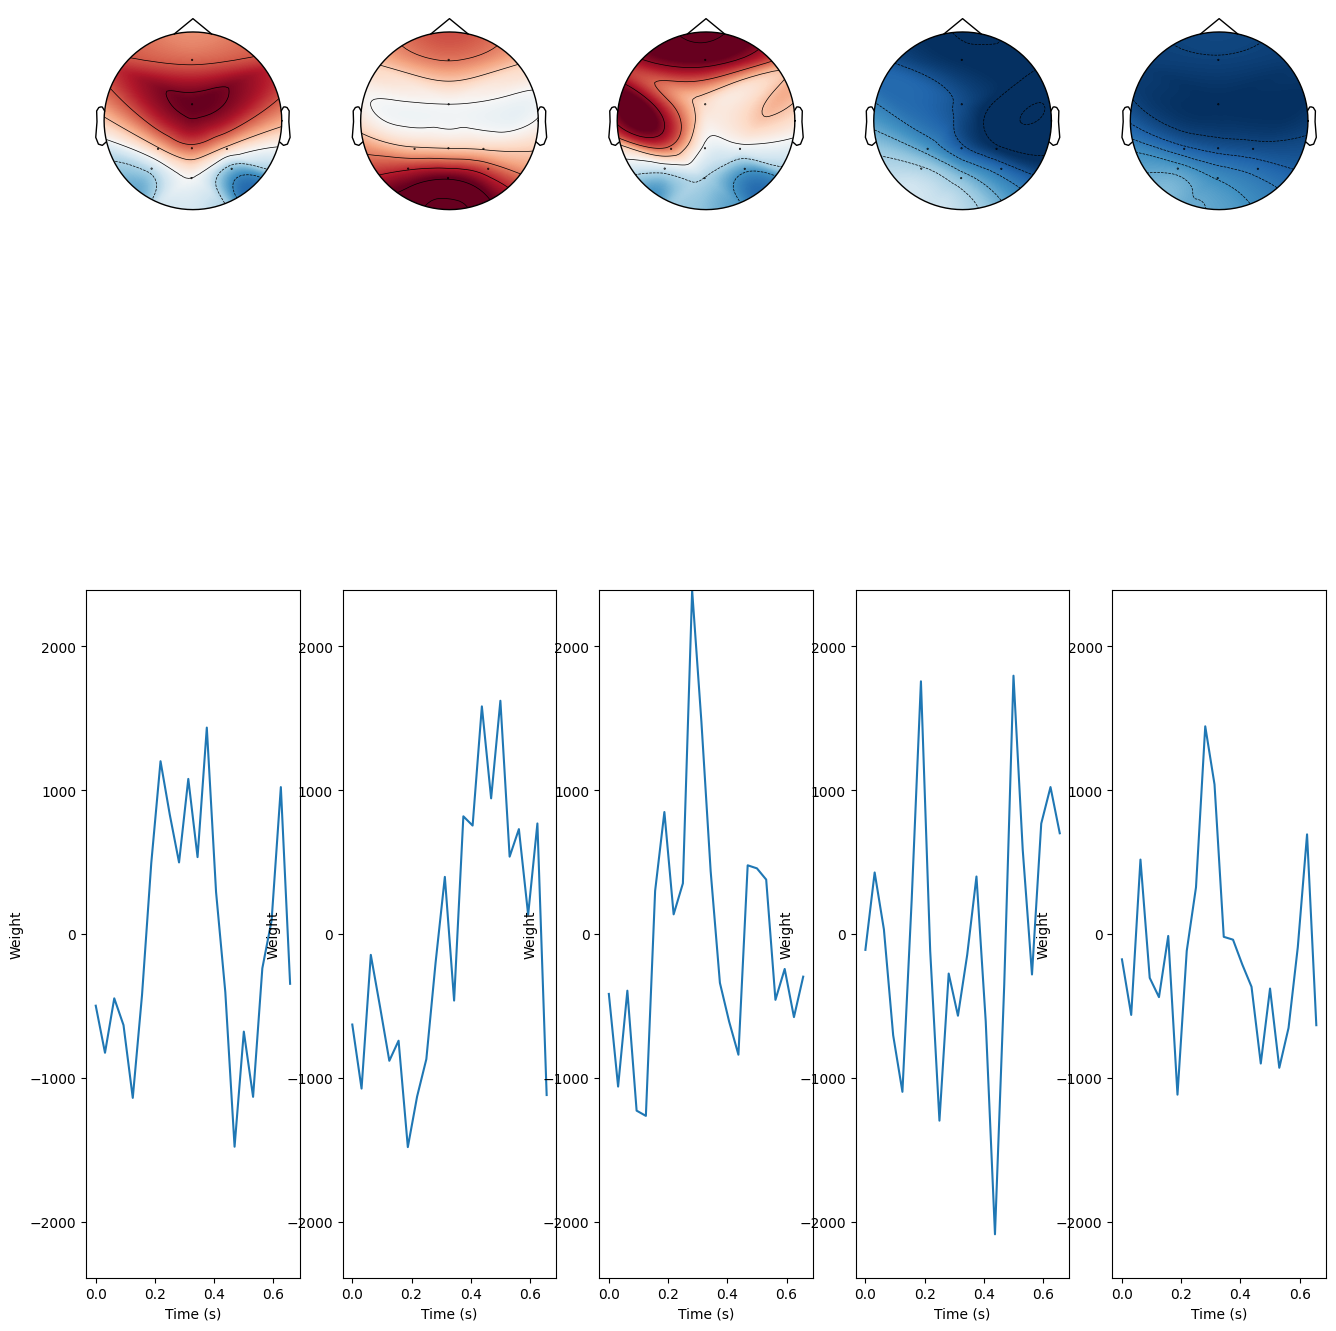

In [14]:
fig, axs = plt.subplots(2,hoda.rank, figsize=(16,6*3))
aps = [factors[k] @ hoda.scatter_w_[k] @ p for k,p in enumerate(hoda.projs_)]
for i in range(hoda.rank):
    w = cupy.asnumpy(aps[0][:,i])
    plot_topomap(w, epochs.info, axes=axs[0,i], show=False)
vmax = np.max(np.abs(aps[1]))
for i in range(hoda.rank):
    w = cupy.asnumpy(aps[1][:,i])
    axs[1,i].plot(epochs.times, w)
    axs[1,i].set_xlabel('Time (s)')
    axs[1,i].set_ylabel('Weight')
    axs[1,i].set_ylim([-vmax, vmax])

In [15]:
Xt_train = cupy.asnumpy(hoda.transform(X_train))
Xt_test = cupy.asnumpy(hoda.transform(X_test))

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA

#classifier = LogisticRegression(penalty='l1', solver='liblinear')
classifier = LDA(solver='lsqr', shrinkage='auto')

classifier.fit(Xt_train,y_train)
classifier.fit(Xt_train,y_train)
feature_order = np.argsort(-np.abs(classifier.coef_))[::-1].squeeze()

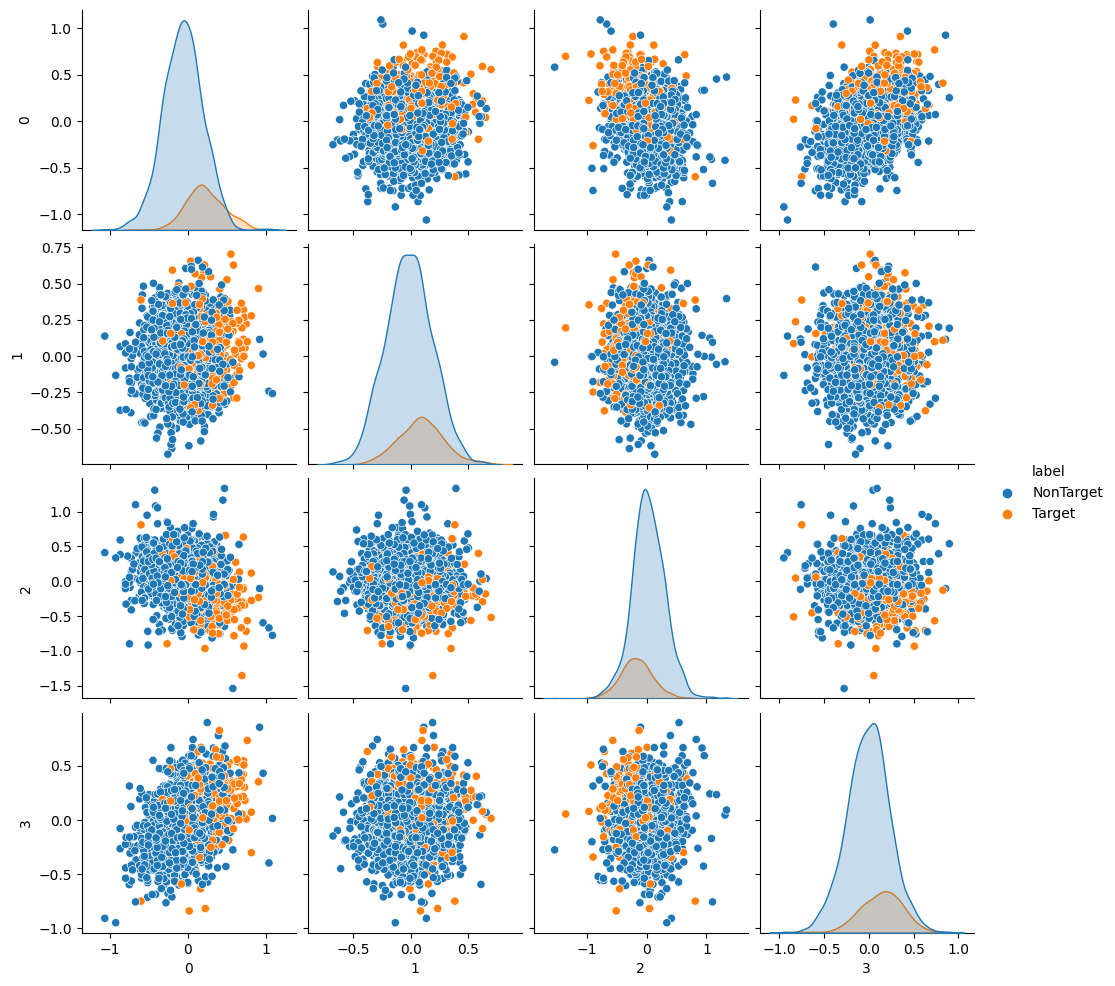

In [17]:
import seaborn as sns
import pandas as pd

n_features = Xt_train.shape[-1]
df_train = pd.DataFrame(Xt_train[:,feature_order[:4]])
df_train['label'] = y_train
g = sns.pairplot(df_train, hue='label')

In [18]:
roc_auc_score(y_train, classifier.predict_proba(Xt_train)[:,1])

0.8715412244897961

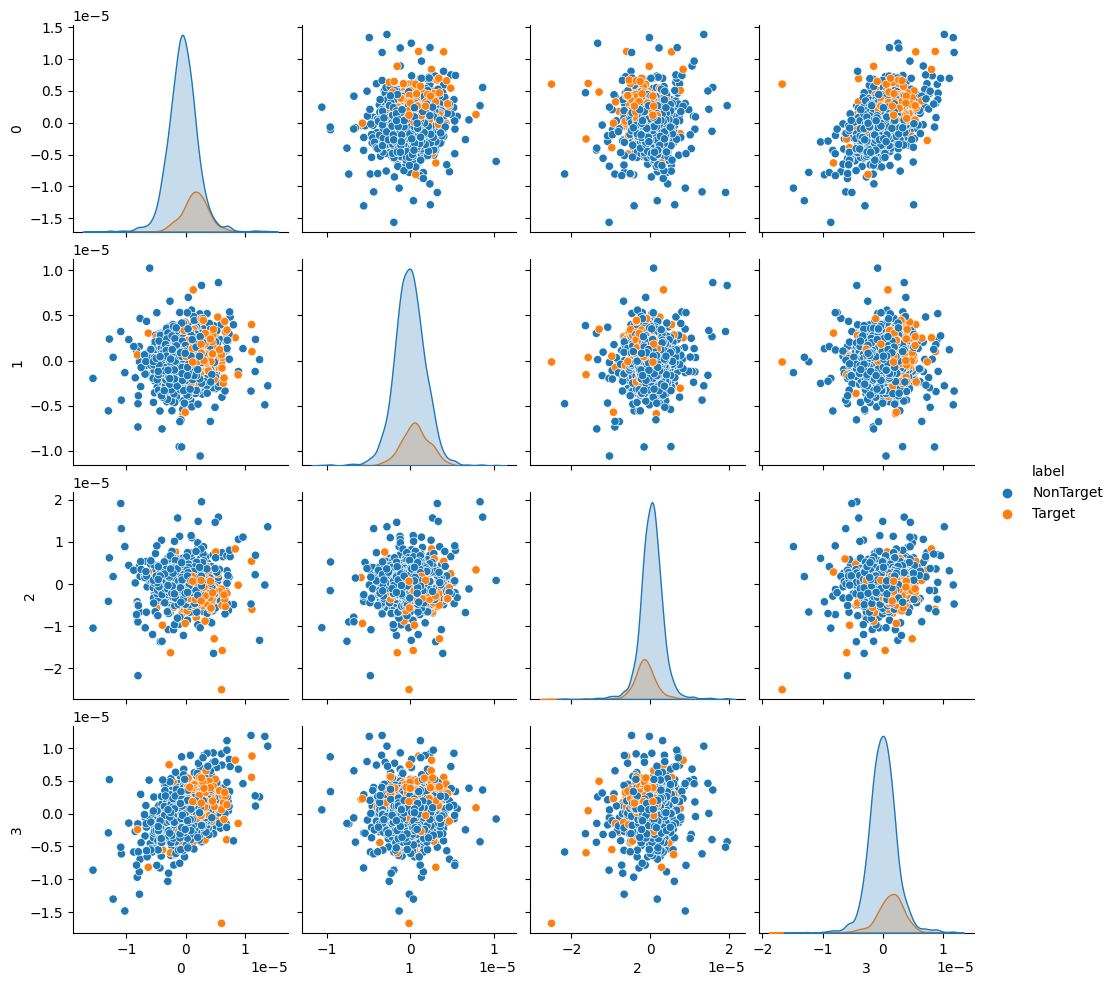

In [19]:
df_test = pd.DataFrame(Xt_test[:,feature_order[:4]])
df_test['label'] = y_test
g = sns.pairplot(df_test, hue='label')

In [20]:
roc_auc_score(y_test, classifier.predict_proba(Xt_test)[:,1])

0.8209681632653062